# BERT for Sentiment Analysis

**Freely modified by Vincent Runge (March 2026)**

___ 

In this notebook we fine-tune **BERT** for binary sentiment analysis on the **SST-2** dataset.

Three regimes are explored:
1. **Feature extraction** — freeze BERT, train only a linear classifier on `[CLS]` embeddings
2. **Full fine-tuning** — jointly update the classifier and all BERT weights
3. **Comparison** — visualise embeddings and analyse errors

**Requirements:**
```
pip install transformers datasets evaluate accelerate scikit-learn matplotlib
```

___

<font color='red'>

**Les objectifs du jour :**

- Réussir à faire tourner ce notebook
- Compréhension de BERT (transformation séquentielle de `[CLS]`)
- Ajouter une analyse du modèle (similaire à (7) pour le TP nanoGPT). Comptage des paramètres et dessin du modèle
- A quoi ressemblent les paramètres de position? (avec BERT mais aussi nanoGPT !?)
- (Bonus) Visualisation de l'attention 

**Objectifs à moyen terme:**

- Adapter le notebook de son choix à un autre use-case de son choix. En étant capable de bien expliquer chaque étape.
- L'objectif: le mettre en avant sur le CV / pour un entretien

___

<font color='blue'>

J'envoie la correction dans quelques jours 

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 1 — Imports and configuration
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

In [172]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print(f'PyTorch version : {torch.__version__}')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device          : {device}')

PyTorch version : 2.6.0
Device          : mps


In [174]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import load_dataset
import evaluate

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 32
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
## 2 — The SST-2 dataset
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


SST-2 is a **binary sentiment dataset (positive / negative)** from movie reviews, part of the GLUE benchmark.

In [177]:
raw_datasets = load_dataset('glue', 'sst2')
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


- 3 datasets, train (67349 obs.), validation (872 obs.) and test  (1821 obs.).
- 3 features: sentence, lable, idx


In [179]:
raw_datasets['train'].shape

(67349, 3)

In [180]:
data_train = raw_datasets['train']

In [181]:
for i in range(20):
    ex = data_train[i]
    label_str = 'positive' if ex['label'] == 1 else 'negative'
    print(f"[{label_str}] {ex['sentence']}")


[negative] hide new secretions from the parental units 
[negative] contains no wit , only labored gags 
[positive] that loves its characters and communicates something rather beautiful about human nature 
[negative] remains utterly satisfied to remain the same throughout 
[negative] on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
[negative] that 's far too tragic to merit such superficial treatment 
[positive] demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . 
[positive] of saucy 
[negative] a depressed fifteen-year-old 's suicidal poetry 
[positive] are more deeply thought through than in most ` right-thinking ' films 
[negative] goes to absurd lengths 
[negative] for those moviegoers who complain that ` they do n't make movies like they used to anymore 
[negative] the part where nothing 's happening , 
[negative] saw how bad this movie was 
[negative] lend some

Negative (0): 29,780   Positive (1): 37,569


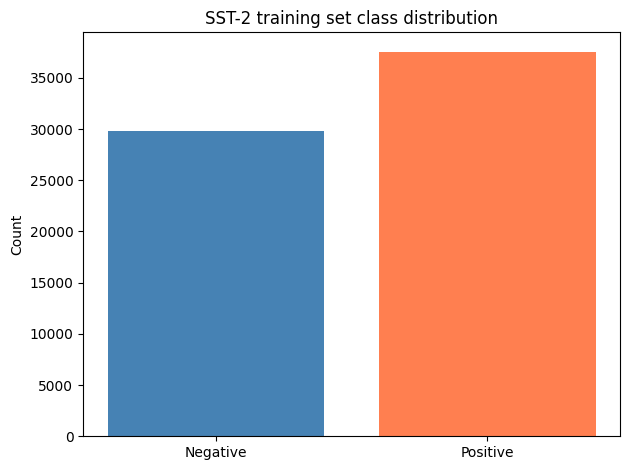

In [182]:
labels = raw_datasets['train']['label']
counts = Counter(labels)
print(f"Negative (0): {counts[0]:,}   Positive (1): {counts[1]:,}")

plt.bar(['Negative', 'Positive'], [counts[0], counts[1]], color=['steelblue', 'coral'])
plt.title('SST-2 training set class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 3 — Tokenisation
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


BERT uses WordPiece tokenisation. Every sequence is wrapped with `[CLS]` at the start and `[SEP]` at the end.

In [184]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [185]:
len(tokenizer)   # vocabulary size

30522

In [186]:
tokenizer.model_max_length     # max sequence length for the model/tokenizer

512

In [187]:
vocab = tokenizer.get_vocab()
id_to_token = {idx: tok for tok, idx in vocab.items()}
print(' // '.join(id_to_token[i] for i in range(1000, 3000)))

" // # // $ // % // & // ' // ( // ) // * // + // , // - // . // / // 0 // 1 // 2 // 3 // 4 // 5 // 6 // 7 // 8 // 9 // : // ; // < // = // > // ? // @ // [ // \ // ] // ^ // _ // ` // a // b // c // d // e // f // g // h // i // j // k // l // m // n // o // p // q // r // s // t // u // v // w // x // y // z // { // | // } // ~ // ¡ // ¢ // £ // ¤ // ¥ // ¦ // § // ¨ // © // ª // « // ¬ // ® // ° // ± // ² // ³ // ´ // µ // ¶ // · // ¹ // º // » // ¼ // ½ // ¾ // ¿ // × // ß // æ // ð // ÷ // ø // þ // đ // ħ // ı // ł // ŋ // œ // ƒ // ɐ // ɑ // ɒ // ɔ // ɕ // ə // ɛ // ɡ // ɣ // ɨ // ɪ // ɫ // ɬ // ɯ // ɲ // ɴ // ɹ // ɾ // ʀ // ʁ // ʂ // ʃ // ʉ // ʊ // ʋ // ʌ // ʎ // ʐ // ʑ // ʒ // ʔ // ʰ // ʲ // ʳ // ʷ // ʸ // ʻ // ʼ // ʾ // ʿ // ˈ // ː // ˡ // ˢ // ˣ // ˤ // α // β // γ // δ // ε // ζ // η // θ // ι // κ // λ // μ // ν // ξ // ο // π // ρ // ς // σ // τ // υ // φ // χ // ψ // ω // а // б // в // г // д // е // ж // з // и // к // л // м // н // о // п // р // с // т // у // ф // 

In [188]:
example = 'This film was absolutely fantastic!'

tokens  = tokenizer.tokenize(example)
encoded = tokenizer(example, return_tensors='pt')

print('Tokens :', tokens)
print('Input IDs:', encoded['input_ids'])
print('Decoded :', tokenizer.decode(encoded['input_ids'][0]))

Tokens : ['this', 'film', 'was', 'absolutely', 'fantastic', '!']
Input IDs: tensor([[  101,  2023,  2143,  2001,  7078, 10392,   999,   102]])
Decoded : [CLS] this film was absolutely fantastic! [SEP]


In [273]:
example = 'This film was aboltely fanastic!'

tokens  = tokenizer.tokenize(example)
encoded = tokenizer(example, return_tensors='pt')

print('Tokens :', tokens)
print('Input IDs:', encoded['input_ids'])
print('Decoded :', tokenizer.decode(encoded['input_ids'][0]))

Tokens : ['this', 'film', 'was', 'ab', '##olt', '##ely', 'fan', '##astic', '!']
Input IDs: tensor([[  101,  2023,  2143,  2001, 11113, 27914, 26006,  5470, 20875,   999,
           102]])
Decoded : [CLS] this film was aboltely fanastic! [SEP]


In [191]:
def tokenize_function(batch):
    return tokenizer(
        batch['sentence'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
    )

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenisation done. Columns:', tokenized_datasets['train'].column_names)

Tokenisation done. Columns: ['sentence', 'labels', 'idx', 'input_ids', 'token_type_ids', 'attention_mask']


In [193]:
tokenized_datasets.reset_format()

for i in range(5):
    ex = tokenized_datasets["train"][i]
    print(f"[{ex['labels']}] {ex['sentence']}")
    print("input_ids:", ex["input_ids"])
    print("token_type_ids:", ex["token_type_ids"])
    print("attention_mask:", ex["attention_mask"])
    print()

tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

[0] hide new secretions from the parental units 
input_ids: [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
token_type_ids: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
## 4 — Regime 1: Feature extraction (frozen BERT)
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Extract `[CLS]` embeddings without updating BERT, then train logistic regression on top.

In [199]:
from datasets.utils.logging import disable_progress_bar
from transformers import logging as hf_logging
from torch.utils.data import DataLoader

disable_progress_bar()
hf_logging.set_verbosity_error()

bert_encoder = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_encoder.eval()

def extract_cls_embeddings(model, dataset, batch_size=64, max_samples=None):
    subset = dataset.select(range(max_samples)) if max_samples else dataset
    loader = DataLoader(subset, batch_size=batch_size)
    all_emb, all_lbl = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out = model(input_ids=ids, attention_mask=mask)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_emb.append(cls)
            all_lbl.append(batch['labels'].numpy())

    return np.concatenate(all_emb), np.concatenate(all_lbl)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [200]:
print('Extracting training embeddings...')
X_train, y_train = extract_cls_embeddings(bert_encoder, tokenized_datasets['train'], max_samples=5000)
print('Extracting validation embeddings...')
X_val, y_val = extract_cls_embeddings(bert_encoder, tokenized_datasets['validation'])


Extracting training embeddings...
Extracting validation embeddings...


In [202]:
print(f'X_train shape: {X_train.shape},  X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape},  y_val shape: {y_val.shape}')

X_train shape: (5000, 768),  X_val shape: (872, 768)
y_train shape: (5000,),  y_val shape: (872,)


In [203]:
X_train[10]

array([-3.28826308e-01,  1.36039019e-01, -1.97260529e-01,  4.99151200e-02,
       -7.02351704e-02, -4.03441638e-01,  3.21131825e-01,  8.91486526e-01,
        3.88592988e-01,  1.91188082e-02, -2.95461327e-01, -2.25371048e-01,
        1.89868107e-01,  3.01449150e-01, -6.11225069e-01,  2.20311671e-01,
        6.75527230e-02,  3.65700305e-01, -4.35688905e-02, -1.20812431e-01,
       -1.08678058e-01, -2.48393975e-04,  4.38558757e-02, -5.97263694e-01,
        4.77434158e-01, -1.85690716e-01, -8.61120373e-02, -4.00738865e-01,
        1.59134269e-02,  1.32464528e-01,  3.43408078e-01,  1.15093634e-01,
       -4.98099811e-02, -4.11447614e-01,  1.80564970e-02, -3.56202364e-01,
        2.38563299e-01,  6.66172445e-01,  4.86993678e-02,  5.26091456e-01,
        5.37420735e-02, -1.11340798e-01,  5.64672351e-01,  1.86065078e-01,
        8.97750109e-02, -8.09584796e-01, -1.97601318e+00,  4.35693935e-03,
       -1.66577324e-01, -5.00753522e-04,  2.79077888e-01, -1.13323502e-01,
        5.44307470e-01, -

In [204]:
y_train[10]

0

In [205]:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

<font color='teal'>


**Comments:**

`bert-base-uncased` produces, for each token in the input sentence, a vector of size 768. `X_train` is the matrix made of the `[CLS]` token representations for all training sentences.
 
The logistic regression sees:

- 5000 input vectors for training
- 872 input vectors for validation
- each input vector has 768 variables


</font>

**RESULTS:**

In [212]:
val_preds  = clf.predict(X_val)
acc_frozen = accuracy_score(y_val, val_preds)
print(f'Validation accuracy (frozen BERT + LR): {acc_frozen:.4f}')

Validation accuracy (frozen BERT + LR): 0.8337


In [215]:
label_name = {0: "negative", 1: "positive"}
val_sentences = raw_datasets["validation"]["sentence"]

for i in range(10):
    true_label = y_val[i]
    pred_label = val_preds[i]
    sentence = val_sentences[i]

    print(f"Sentence : {sentence}")
    print(f"True     : {label_name[int(true_label)]}")
    print(f"Predicted: {label_name[int(pred_label)]}")
    print(f"Correct  : {true_label == pred_label}")
    print("-" * 60)

Sentence : it 's a charming and often affecting journey . 
True     : positive
Predicted: positive
Correct  : True
------------------------------------------------------------
Sentence : unflinchingly bleak and desperate 
True     : negative
Predicted: positive
Correct  : False
------------------------------------------------------------
Sentence : allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
True     : positive
Predicted: positive
Correct  : True
------------------------------------------------------------
Sentence : the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 
True     : positive
Predicted: positive
Correct  : True
------------------------------------------------------------
Sentence : it 's slow -- very , very slow . 
True     : negative
Predicted: negative
Correct  : True
------------------------------------------------------------
Sentence : altho

In [218]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_preds)
print(cm)

[[340  88]
 [ 57 387]]


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 5 — Regime 2: Full fine-tuning
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Train BERT + classification head jointly using the HuggingFace `Trainer` API.

In [221]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [222]:
model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir='./bert_sst2_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    seed=SEED,
    report_to='none',
)

TRAIN_SUBSET = 5000  # set to None to use the full training set (5000)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=tokenized_datasets['train'].select(range(TRAIN_SUBSET)),
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

# Remove the NotebookProgressCallback that conflicts with nbconvert execution
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.pop_callback(NotebookProgressCallback)
except Exception:
    pass

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'eval_loss': '0.2714', 'eval_accuracy': '0.8968', 'eval_runtime': '17.63', 'eval_samples_per_second': '49.46', 'eval_steps_per_second': '1.588', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.2417', 'eval_accuracy': '0.9071', 'eval_runtime': '19.11', 'eval_samples_per_second': '45.63', 'eval_steps_per_second': '1.465', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.2875', 'eval_accuracy': '0.9094', 'eval_runtime': '19.1', 'eval_samples_per_second': '45.65', 'eval_steps_per_second': '1.466', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1377', 'train_samples_per_second': '10.89', 'train_steps_per_second': '0.342', 'train_loss': '0.2533', 'epoch': '3'}


TrainOutput(global_step=471, training_loss=0.253304078573887, metrics={'train_runtime': 1377.0978, 'train_samples_per_second': 10.892, 'train_steps_per_second': 0.342, 'train_loss': 0.253304078573887, 'epoch': 3.0})

In [223]:
results_ft = trainer.evaluate()
acc_ft     = results_ft['eval_accuracy']
print(f'Validation accuracy (fine-tuned BERT):  {acc_ft:.4f}')
print(f'Improvement over frozen BERT:           +{acc_ft - acc_frozen:.4f}')

{'eval_loss': '0.2419', 'eval_accuracy': '0.906', 'eval_runtime': '17.68', 'eval_samples_per_second': '49.33', 'eval_steps_per_second': '1.584', 'epoch': '3'}
Validation accuracy (fine-tuned BERT):  0.9060
Improvement over frozen BERT:           +0.0722


In [225]:
pred_output = trainer.predict(tokenized_datasets["validation"])
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids
cmFull = confusion_matrix(y_true, y_pred)
print(cmFull)

[[378  50]
 [ 32 412]]


**Previous result with the Logistic Regression only:**

In [227]:
cm = confusion_matrix(y_val, val_preds)
print(cm)

[[340  88]
 [ 57 387]]


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 6 — Visualise CLS embeddings with PCA
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Project 768-dimensional `[CLS]` embeddings to 2D and compare **before** and **after** fine-tuning.

Extracting fine-tuned validation embeddings...


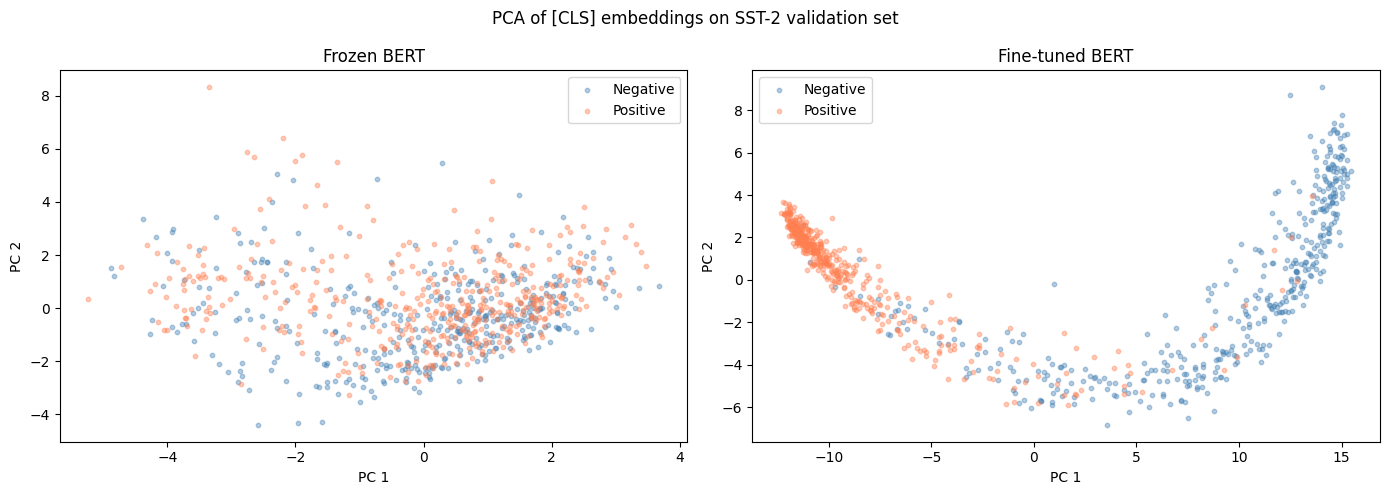

In [229]:
from sklearn.decomposition import PCA

ft_encoder = model_ft.bert.to(device)
ft_encoder.eval()

print('Extracting fine-tuned validation embeddings...')
X_val_ft, y_val_ft = extract_cls_embeddings(ft_encoder, tokenized_datasets['validation'])

Z_frozen = PCA(n_components=2, random_state=SEED).fit_transform(X_val)
Z_ft     = PCA(n_components=2, random_state=SEED).fit_transform(X_val_ft)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, y, title in zip(
    axes,
    [Z_frozen, Z_ft],
    [y_val, y_val_ft],
    ['Frozen BERT', 'Fine-tuned BERT'],
):
    for label, color, name in [(0, 'steelblue', 'Negative'), (1, 'coral', 'Positive')]:
        mask = (y == label)
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=name, alpha=0.4, s=10)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
plt.suptitle('PCA of [CLS] embeddings on SST-2 validation set')
plt.tight_layout()
plt.show()

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 7 — Error analysis
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Examine the sentences the fine-tuned model gets wrong.

In [231]:
predictions = trainer.predict(tokenized_datasets['validation'])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

val_sentences = raw_datasets['validation']['sentence']
errors = [
    {'sentence': val_sentences[i], 'true': int(true_labels[i]), 'pred': int(pred_labels[i])}
    for i in range(len(true_labels))
    if true_labels[i] != pred_labels[i]
]

label_name = {0: 'negative', 1: 'positive'}
print(f'Misclassified: {len(errors)} / {len(true_labels)} ({100*len(errors)/len(true_labels):.1f}%)')
print()
for err in errors[:10]:
    t = label_name[err['true']]
    p = label_name[err['pred']]
    print(f'  True: {t:<10}  Pred: {p}')
    print(f'  {repr(err["sentence"])}')
    print()

Misclassified: 82 / 872 (9.4%)

  True: negative    Pred: positive
  'pumpkin takes an admirable look at the hypocrisy of political correctness , but it does so with such an uneven tone that you never know when humor ends and tragedy begins . '

  True: negative    Pred: positive
  'holden caulfield did it better . '

  True: negative    Pred: positive
  'a synthesis of cliches and absurdities that seems positively decadent in its cinematic flash and emptiness . '

  True: negative    Pred: positive
  'it feels like an after-school special gussied up with some fancy special effects , and watching its rote plot points connect is about as exciting as gazing at an egg timer for 93 minutes . '

  True: negative    Pred: positive
  'manages to be both repulsively sadistic and mundane . '

  True: negative    Pred: positive
  "the script kicks in , and mr. hartley 's distended pace and foot-dragging rhythms follow . "

  True: positive    Pred: negative
  "though it 's become almost redundan

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 8 — Inference on custom sentences
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Use the fine-tuned model to predict sentiment on new sentences.

In [233]:
from transformers import pipeline

sentiment_pipe = pipeline(
    'sentiment-analysis',
    model=model_ft,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

custom_sentences = [
    'The acting was superb and the story deeply moving.',
    'A dull, predictable waste of two hours.',
    'Not bad, but not particularly memorable either.',
    'One of the best films I have seen this year!',
    'The plot made no sense whatsoever.',
]

results = sentiment_pipe(custom_sentences)
for sentence, result in zip(custom_sentences, results):
    print(f"[{result['label']}  {result['score']:.3f}]  {sentence}")

[LABEL_1  0.992]  The acting was superb and the story deeply moving.
[LABEL_0  0.984]  A dull, predictable waste of two hours.
[LABEL_0  0.951]  Not bad, but not particularly memorable either.
[LABEL_1  0.990]  One of the best films I have seen this year!
[LABEL_0  0.980]  The plot made no sense whatsoever.


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 9 — Optional: attention visualisation
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


BERT returns attention weights for each of its 144 heads (12 layers × 12 heads). We inspect which tokens the model focuses on.

In [235]:
from transformers import BertModel

sentence = 'The film was surprisingly good despite a weak script.'
inputs   = tokenizer(sentence, return_tensors='pt').to(device)

# attn_implementation must be set at model creation, not forward time.
# We create a fresh BertModel with 'eager' attention and copy fine-tuned weights.
bert_eager = BertModel.from_pretrained(
    MODEL_NAME, attn_implementation='eager'
).to(device)
bert_eager.load_state_dict(model_ft.bert.state_dict())
bert_eager.eval()

with torch.no_grad():
    outputs = bert_eager(**inputs, output_attentions=True)

tokens   = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
n_layers = len(outputs.attentions)
print(f'Sequence length: {len(tokens)},  Layers: {n_layers},  '
      f'Heads per layer: {outputs.attentions[0].shape[1]}')
print('Tokens:', tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Sequence length: 12,  Layers: 12,  Heads per layer: 12
Tokens: ['[CLS]', 'the', 'film', 'was', 'surprisingly', 'good', 'despite', 'a', 'weak', 'script', '.', '[SEP]']


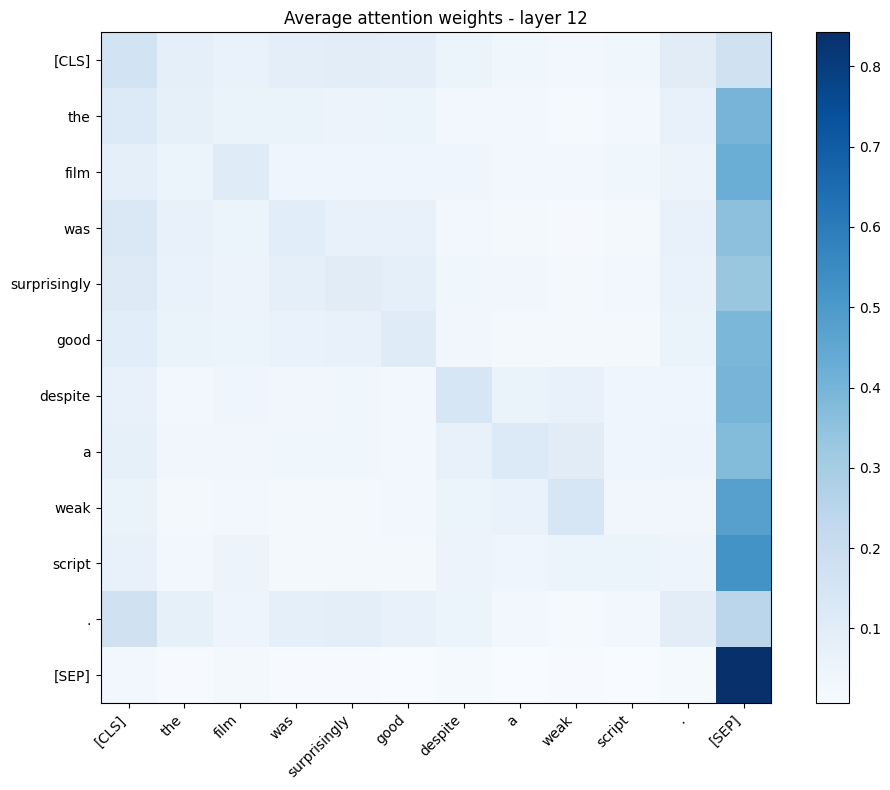

In [236]:
layer_idx = 11  # last layer
attn = outputs.attentions[layer_idx][0].mean(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attn, cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
plt.colorbar(im, ax=ax)
ax.set_title(f'Average attention weights - layer {layer_idx + 1}')
plt.tight_layout()
plt.show()